In [1]:
!pip install scikit-surprise pandas numpy matplotlib seaborn tqdm

In [2]:
# I have written this code as ram usage becomes 100% and system crashes
import gc
import os

def free_ram():
    """Aggressively frees system RAM."""
    gc.collect()
    try:
        from numba import cuda
        cuda.current_context().deallocations.clear()
    except:
        pass

def ram_status():
    """Prints current RAM usage."""
    import psutil
    ram = psutil.virtual_memory()
    print(f"Used: {ram.used/1e9:.2f} GB / {ram.total/1e9:.2f} GB ({ram.percent}%)")

ram_status()

Used: 1.06 GB / 13.61 GB (10.2%)


### Parse Raw Data

This step reads `combined_data_1.txt`, extracts `user_id`, `movie_id`, and `rating`, and converts them into a pandas DataFrame with optimized data types.

In [3]:
import pandas as pd
import gc

data_path = '/content/drive/MyDrive/netflix_prize/combined_data_1.txt'

rows_to_read = 600000
data = []
current_movie_id = -1
count = 0

with open(data_path, 'r') as f:
    for line in f:
        line = line.strip()
        if line.endswith(':'):
            current_movie_id = int(line[:-1])
        else:
            user_id, rating, _ = line.split(',')
            data.append([int(user_id), current_movie_id, int(rating)])
            count += 1
            if count >= rows_to_read:
                break

df = pd.DataFrame(data, columns=['user_id', 'movie_id', 'rating'])
del data
gc.collect()

df['user_id'] = df['user_id'].astype('int32')
df['movie_id'] = df['movie_id'].astype('int32')
df['rating'] = df['rating'].astype('int8')

display(df.head())
print(f"Shape after initial parse: {df.shape}")
ram_status()

,user_id,movie_id,rating
0,1488844,1,3
1,822109,1,5
2,885013,1,4
3,30878,1,4
4,823519,1,3


Shape after initial parse: (600000, 3)
Used: 0.94 GB / 13.61 GB (9.4%)


### Filter Data

This step aggressively filters out inactive users and unpopular movies to significantly reduce the dataset size while retaining meaningful data for the recommendation model.

In [4]:
# Compute ratings per user and per movie
ratings_per_user = df['user_id'].value_counts()
ratings_per_movie = df['movie_id'].value_counts()

# Identify active users (>=30 ratings) and popular movies (>=50 ratings)
active_users = ratings_per_user[ratings_per_user >= 30].index
popular_movies = ratings_per_movie[ratings_per_movie >= 50].index

# Apply filters
df = df[df['user_id'].isin(active_users)]
df = df[df['movie_id'].isin(popular_movies)]

del ratings_per_user, ratings_per_movie
gc.collect()

print(f"Shape after filtering: {df.shape}")
print(f"Unique users after filtering: {df['user_id'].nunique()}")
print(f"Unique movies after filtering: {df['movie_id'].nunique()}")
ram_status()

Shape after filtering: (5699, 3)
Unique users after filtering: 120
Unique movies after filtering: 175
Used: 0.91 GB / 13.61 GB (9.2%)


### Downsample and Optimize Data Types

This step samples the filtered data (if needed) and converts `user_id` and `movie_id` to `category` dtype for further memory optimization. Note that the dataset size is now driven by filtering, not a fixed sample size.

In [5]:
# Ensure we don't try to sample more rows than available. Dataset size is already reduced by filtering.
sample_size = df.shape[0]
df = df.sample(n=sample_size, random_state=42).reset_index(drop=True)

# Convert to category dtype for memory efficiency
df['user_id'] = df['user_id'].astype('category')
df['movie_id'] = df['movie_id'].astype('category')

print(f"Final shape after sampling: {df.shape}")
print("Final dtypes:")
print(df.dtypes)
ram_status()

Final shape after sampling: (5699, 3)
Final dtypes:
user_id     category
movie_id    category
rating          int8
dtype: object
Used: 0.78 GB / 13.61 GB (8.2%)


### Load Movie Titles and Merge

This step loads movie titles, merges them with the main DataFrame, and cleans up memory.

In [6]:
movie_titles_path = '/content/drive/MyDrive/netflix_prize/movie_titles.csv'

# Load movie titles, specifying data types and handling parsing issues for robustness
movies_df = pd.read_csv(
    movie_titles_path,
    header=None,
    names=['movie_id','year','title'],
    encoding='ISO-8859-1',
    sep=',',
    quotechar='"',
    engine='python',
    on_bad_lines='skip'
)

# Keep only movie_id and title, and optimize movie_id dtype
movies_df = movies_df[['movie_id', 'title']]
movies_df['movie_id'] = movies_df['movie_id'].astype('int32')

# Perform a left merge to keep all rows from df
df = pd.merge(df, movies_df, on='movie_id', how='left')

# Fill missing titles with 'Unknown'
df['title'] = df['title'].fillna('Unknown')

del movies_df
gc.collect()

display(df.head(3))

# Save processed data for clean reload
df.to_csv('/content/netflix_lean.csv', index=False)

del df
gc.collect()

ram_status()

,user_id,movie_id,rating,title
0,2439493,46,5,Rudolph the Red-Nosed Reindeer
1,322009,26,4,Never Die Alone
2,1664010,145,4,Get Out Your Handkerchiefs


Used: 0.82 GB / 13.61 GB (8.5%)


### Reload Optimized Data

This final step reloads the saved, lean dataset to ensure it's ready for further processing with optimized memory usage.

In [7]:
df = pd.read_csv(
    '/content/netflix_lean.csv',
    dtype={
        'user_id': 'category',
        'movie_id': 'category',
        'rating': 'int8'
    }
)

print(f"Shape after reloading: {df.shape}")
ram_status()

display(df.head())

Shape after reloading: (5699, 4)
Used: 0.82 GB / 13.61 GB (8.5%)


,user_id,movie_id,rating,title
0,2439493,46,5,Rudolph the Red-Nosed Reindeer
1,322009,26,4,Never Die Alone
2,1664010,145,4,Get Out Your Handkerchiefs
3,789014,46,4,Rudolph the Red-Nosed Reindeer
4,1461435,79,1,The Killing


### RAM-Safe Exploratory Data Analysis (EDA)

Perform data distribution and sparsity analysis while carefully managing memory.

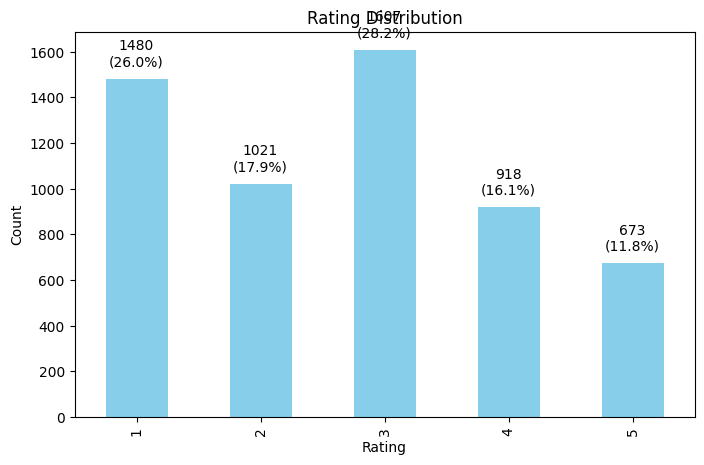

Mean Rating: 2.70
% Ratings >= 4: 27.9%
Used: 0.89 GB / 13.61 GB (9.0%)


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import gc

# --- ANALYSIS 1: RATING DISTRIBUTION ---
counts = df['rating'].value_counts().sort_index()
total = len(df)

plt.figure(figsize=(8, 5))
ax = counts.plot(kind='bar', color='skyblue')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')

# Label bars
for i, v in enumerate(counts):
    ax.text(i, v + (total*0.01), f"{v}\n({v/total:.1%})", ha='center')

plt.show()
plt.savefig('eda_1_ratings.png')
plt.close()

print(f"Mean Rating: {df['rating'].mean():.2f}")
print(f"% Ratings >= 4: {(df['rating'] >= 4).mean():.1%}")

del counts
gc.collect()
ram_status()

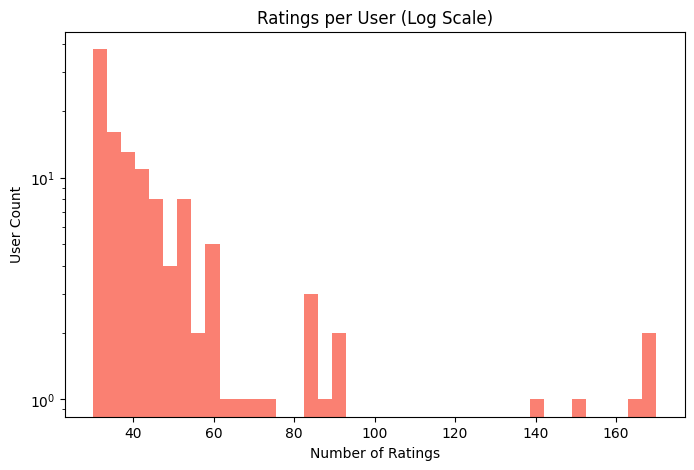

Median ratings per user: 38.5
% of users with < 50 ratings: 74.2%


11659

In [9]:
# --- ANALYSIS 2: USER ACTIVITY ---
user_counts = df.groupby('user_id', observed=True)['rating'].count()

plt.figure(figsize=(8, 5))
plt.hist(user_counts, bins=40, color='salmon')
plt.yscale('log')
plt.title('Ratings per User (Log Scale)')
plt.xlabel('Number of Ratings')
plt.ylabel('User Count')

plt.show()
plt.savefig('eda_2_users.png')
plt.close()

print(f"Median ratings per user: {user_counts.median()}")
print(f"% of users with < 50 ratings: {(user_counts < 50).mean():.1%}")

del user_counts
gc.collect()

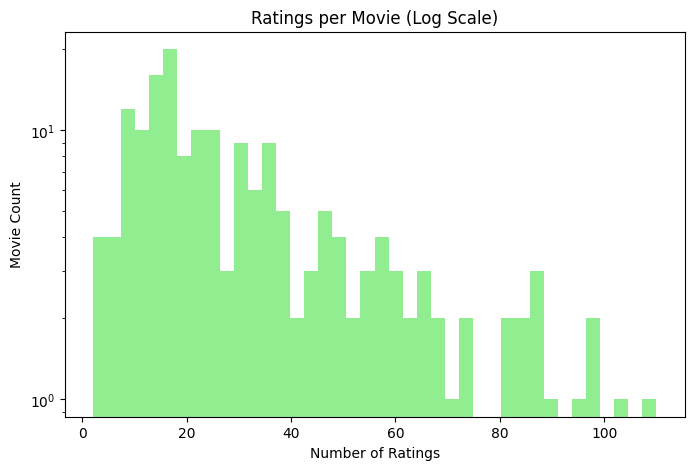

Top 10 Most Rated Movies:
                     title  count
                  The Game    110
    Something's Gotta Give    102
                     Congo     99
Rambo: First Blood Part II     97
               Dragonheart     96
                      Fame     90
                  Silkwood     88
           Lilo and Stitch     88
                   Spartan     86
            Sweet November     84


10906

In [10]:
# --- ANALYSIS 3: MOVIE POPULARITY ---
movie_counts = df.groupby('movie_id', observed=True)['rating'].count()

plt.figure(figsize=(8, 5))
plt.hist(movie_counts, bins=40, color='lightgreen')
plt.yscale('log')
plt.title('Ratings per Movie (Log Scale)')
plt.xlabel('Number of Ratings')
plt.ylabel('Movie Count')

plt.show()
plt.savefig('eda_3_movies.png')
plt.close()

# Top 10 movies
top_10_ids = movie_counts.sort_values(ascending=False).head(10)
top_10_movies = df[df['movie_id'].isin(top_10_ids.index)][['movie_id', 'title']].drop_duplicates()
top_10_display = top_10_movies.merge(top_10_ids.rename('count'), on='movie_id').sort_values('count', ascending=False)

print("Top 10 Most Rated Movies:")
print(top_10_display[['title', 'count']].to_string(index=False))

del movie_counts, top_10_ids, top_10_movies, top_10_display
gc.collect()

Unique Users: 120
Unique Movies: 175
Total Ratings: 5699
Matrix Sparsity: 72.86%


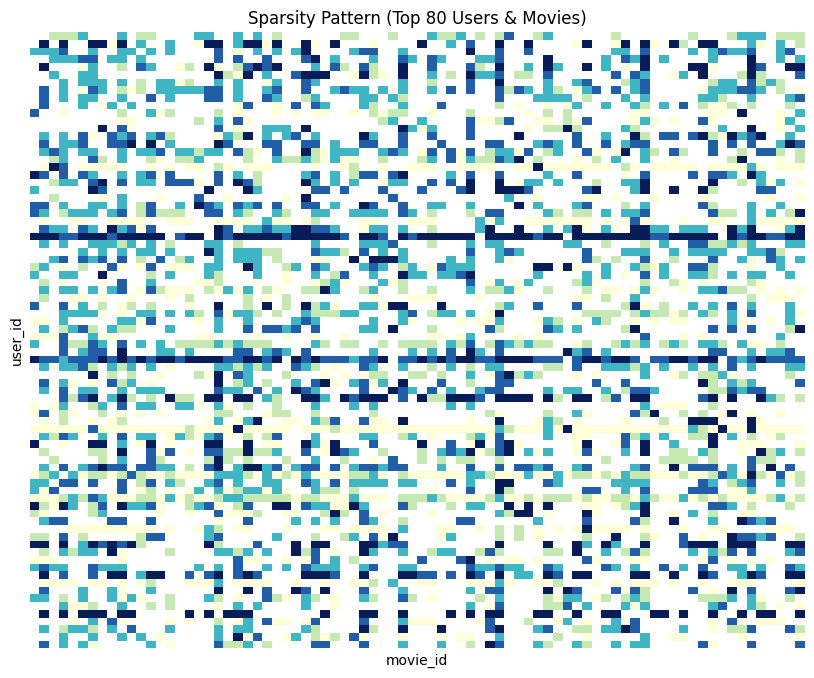

1779

In [11]:
# --- ANALYSIS 4: SPARSITY ---
n_users = df['user_id'].nunique()
n_movies = df['movie_id'].nunique()
n_ratings = len(df)
sparsity = (1 - n_ratings / (n_users * n_movies)) * 100

print(f"Unique Users: {n_users}")
print(f"Unique Movies: {n_movies}")
print(f"Total Ratings: {n_ratings}")
print(f"Matrix Sparsity: {sparsity:.2f}%")

# Tiny 80x80 Heatmap
top_u = df['user_id'].value_counts().head(80).index
top_m = df['movie_id'].value_counts().head(80).index
sample_df = df[df['user_id'].isin(top_u) & df['movie_id'].isin(top_m)]

pivot_small = sample_df.pivot_table(index='user_id', columns='movie_id', values='rating', observed=True)

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_small, cbar=False, cmap='YlGnBu', xticklabels=False, yticklabels=False)
plt.title('Sparsity Pattern (Top 80 Users & Movies)')

plt.show()
plt.savefig('eda_4_sparsity.png')
plt.close()

del sample_df, pivot_small, top_u, top_m
gc.collect()

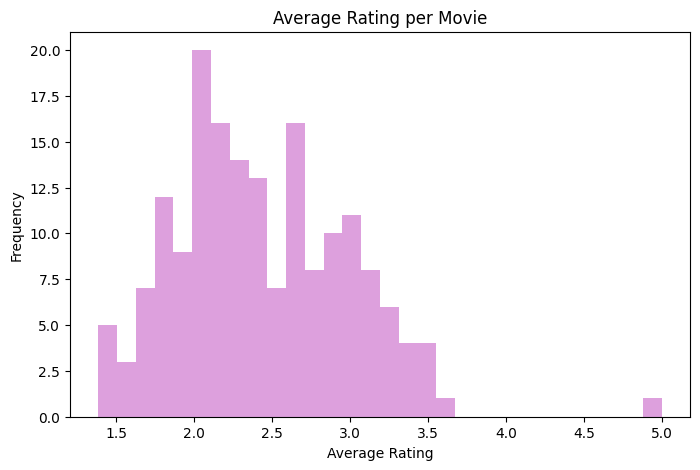

Std of avg ratings: 0.560
Min avg rating: 1.38
Max avg rating: 5.00

EDA complete
Used: 0.98 GB / 13.61 GB (9.7%)


In [12]:
# --- ANALYSIS 5: AVG RATING PER MOVIE ---
avg_ratings = df.groupby('movie_id', observed=True)['rating'].mean()

plt.figure(figsize=(8, 5))
plt.hist(avg_ratings, bins=30, color='plum')
plt.title('Average Rating per Movie')
plt.xlabel('Average Rating')
plt.ylabel('Frequency')

plt.show()
plt.savefig('eda_5_avg.png')
plt.close()

print(f"Std of avg ratings: {avg_ratings.std():.3f}")
print(f"Min avg rating: {avg_ratings.min():.2f}")
print(f"Max avg rating: {avg_ratings.max():.2f}")

del avg_ratings
gc.collect()

print("\nEDA complete")
ram_status()

### Prepare Surprise Data

Convert the pandas DataFrame into a Surprise-compatible dataset using an 80/20 train-test split for model training and evaluation.

In [13]:
from surprise import Reader, Dataset, SVD, accuracy
from surprise.model_selection import train_test_split
import time

# Reader for the rating scale
reader = Reader(rating_scale=(1, 5))

# Load only necessary columns for Surprise to minimize memory usage
data = Dataset.load_from_df(df[['user_id', 'movie_id', 'rating']], reader)

# 80/20 split for training and testing
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

print(f"Train size: {trainset.n_ratings} ratings")
print(f"Test size: {len(testset)} ratings")

# Explicit cleanup of Surprise intermediate data structures
del data
gc.collect()

Train size: 4559 ratings
Test size: 1140 ratings


205

### Train SVD Model

Train a Singular Value Decomposition (SVD) model with `n_factors=20` to keep the model lightweight and efficient.

In [14]:
start_time = time.time()

# Initialize SVD with low RAM parameters
svd_model = SVD(
    n_factors=20,
    n_epochs=15,
    lr_all=0.005,
    reg_all=0.02,
    random_state=42
)

# Train the model
svd_model.fit(trainset)

duration = time.time() - start_time
print(f"SVD trained in {duration:.2f} seconds")

gc.collect()

SVD trained in 0.07 seconds


0

### Evaluate Model Performance with RMSE, MAE, and MAP@10

Calculate Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE) for rating prediction accuracy. Implement a memory-efficient Mean Average Precision (MAP) function to assess ranking quality of top-10 recommendations.

In [15]:
from collections import defaultdict

# Evaluate RMSE and MAE
predictions = svd_model.test(testset)
svd_rmse = accuracy.rmse(predictions, verbose=True)
svd_mae = accuracy.mae(predictions, verbose=True)

def compute_map_at_k_lean(predictions, k=10, threshold=3.5):
    """Memory-efficient MAP@K calculation, grouping predictions by user ID."""
    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    user_aps = []
    skipped = 0

    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        top_k = user_ratings[:k]

        hits = 0
        sum_prec = 0
        relevant_items = [r for _, r in user_ratings if r >= threshold]
        num_relevant = len(relevant_items)

        if num_relevant == 0:
            skipped += 1
            continue

        for i, (est, true_r) in enumerate(top_k):
            if true_r >= threshold:
                hits += 1
                sum_prec += hits / (i + 1)

        user_aps.append(sum_prec / min(num_relevant, k))

    print(f"Users evaluated: {len(user_aps)}")
    print(f"Users skipped (no relevant items): {skipped}")
    return sum(user_aps) / len(user_aps) if user_aps else 0

map_score = compute_map_at_k_lean(predictions, k=10)
print(f"MAP@10: {map_score:.4f}")

del predictions
gc.collect()
ram_status()

RMSE: 0.9673
MAE:  0.7545
Users evaluated: 96
Users skipped (no relevant items): 24
MAP@10: 0.6171
Used: 1.00 GB / 13.61 GB (9.8%)


### Recommendation Function

Define a function to generate top-K recommendations for items a user has not yet rated.

In [16]:
def get_top_k_svd(user_id, k=10):
    """Generates top-K SVD recommendations for a given user_id."""
    all_movie_ids = df['movie_id'].unique()
    rated_movies = set(df[df['user_id'] == user_id]['movie_id'])
    unrated_movies = [m for m in all_movie_ids if m not in rated_movies]

    # Predict ratings for unrated movies
    predictions = [(movie_id, svd_model.predict(user_id, movie_id).est) for movie_id in unrated_movies]
    predictions.sort(key=lambda x: x[1], reverse=True)

    # Create a DataFrame for recommendations and merge titles
    top_k_df = pd.DataFrame(predictions[:k], columns=['movie_id', 'predicted_rating'])
    title_map = df[['movie_id', 'title']].drop_duplicates()
    top_k_df = top_k_df.merge(title_map, on='movie_id', how='left')

    del title_map
    return top_k_df

### Recommendation Demo

Demonstrate the recommendation function by finding active users and generating personalized recommendations for them.

In [17]:
# Find users with >= 40 ratings
active_users_to_demo = df['user_id'].value_counts()
active_users_to_demo = active_users_to_demo[active_users_to_demo >= 40].head(3).index.tolist()

for uid in active_users_to_demo:
    print(f"\n--- RECOMMENDATIONS FOR USER {uid} ---")

    print("Existing top 5 ratings:")
    top_actual = df[df['user_id'] == uid].sort_values('rating', ascending=False).head(5)
    print(top_actual[['title', 'rating']].to_string(index=False))

    print("\nTop 10 SVD Recommendations:")
    recs = get_top_k_svd(uid, k=10)
    print(recs[['title', 'predicted_rating']].to_string(index=False))

    del top_actual, recs
    gc.collect()

ram_status()


--- RECOMMENDATIONS FOR USER 305344 ---
Existing top 5 ratings:
                           title  rating
                        Silkwood       5
Neil Diamond: Greatest Hits Live       5
                         Unknown       4
              Jingle All the Way       4
         Where Sleeping Dogs Lie       4

Top 10 SVD Recommendations:
                                                                      title  predicted_rating
                                                             Reservoir Dogs          2.518095
                                 Jonah: A VeggieTales Movie: Bonus Material          1.974401
Lord of the Rings: The Return of the King: Extended Edition: Bonus Material          1.911729
                                      The Battle of Algiers: Bonus Material          1.706671
                                                                 Elfen Lied          1.672655

--- RECOMMENDATIONS FOR USER 387418 ---
Existing top 5 ratings:
                     title  rat

In [18]:
import pickle
from tabulate import tabulate

# Ensure best_model is loaded or use current svd_model
if 'best_model' not in globals():
    try:
        with open('/content/best_svd_model.pkl', 'rb') as f:
            best_model = pickle.load(f)
        print("Successfully loaded best_svd_model.pkl")
    except FileNotFoundError:
        best_model = svd_model
        print("Pickle not found, falling back to current svd_model")

print("--- SUCCESS CASE ---")
# Find a high-activity user with positive ratings
user_stats = df[df['rating'] >= 4].groupby('user_id', observed=True)['rating'].count()
eligible_users = user_stats[user_stats >= 5].index

# Filter for users with total ratings >= 40
activity_stats = df.groupby('user_id', observed=True)['rating'].count()
success_uid = activity_stats.loc[eligible_users][activity_stats >= 40].index[0]

print(f"Analyzing Success Case for User: {success_uid}")
actual_top = df[df['user_id'] == success_uid].sort_values('rating', ascending=False).head(6)
print("\nActual Top Ratings:")
print(tabulate(actual_top[['title', 'rating']], headers='keys', tablefmt='psql', showindex=False))

recs = get_top_k_svd(success_uid, k=10)
print("\nSVD Top-10 Recommendations:")
print(tabulate(recs[['title', 'predicted_rating']], headers='keys', tablefmt='psql', showindex=False))

del user_stats, eligible_users, activity_stats, actual_top, recs
gc.collect()

Pickle not found, falling back to current svd_model
--- SUCCESS CASE ---
Analyzing Success Case for User: 1028463

Actual Top Ratings:
+-----------------------------------------+----------+
| title                                   |   rating |
|-----------------------------------------+----------|
| Smokey and the Bandit Part 3            |        5 |
| Something's Gotta Give                  |        5 |
| Ferngully 2: The Magical Rescue         |        5 |
| Richard Pryor: Live on the Sunset Strip |        5 |
| Spartan                                 |        5 |
| Justice League                          |        5 |
+-----------------------------------------+----------+

SVD Top-10 Recommendations:
+-------------------------------------------------------+--------------------+
| title                                                 |   predicted_rating |
|-------------------------------------------------------+--------------------|
| Reservoir Dogs                                 

0

In [19]:
print("--- FAILURE CASE ---")

def get_per_user_ap(predictions, k=10, threshold=3.5):
    """Calculates Average Precision for each user given predictions."""
    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    user_aps = {}
    for uid, user_ratings in user_est_true.items():
        relevant_items = [r for _, r in user_ratings if r >= threshold]
        if len(relevant_items) < 3: continue # Skip users with too few relevant items

        user_ratings.sort(key=lambda x: x[0], reverse=True)
        top_k = user_ratings[:k]
        hits = 0
        sum_prec = 0
        for i, (est, true_r) in enumerate(top_k):
            if true_r >= threshold:
                hits += 1
                sum_prec += hits / (i + 1)
        user_aps[uid] = sum_prec / min(len(relevant_items), k)
    return user_aps

# Evaluate testset to get per-user APs
preds = best_model.test(testset)
aps = get_per_user_ap(preds, k=10)

# Find user with lowest AP among those with at least 3 relevant items
failure_uid = min(aps, key=aps.get)
print(f"Analyzing Failure Case for User: {failure_uid} (AP@10: {aps[failure_uid]:.4f})")

# Create a title lookup and get actual liked movies for the failure case
title_lookup = df[['movie_id', 'title']].drop_duplicates().set_index('movie_id')['title'].to_dict()
relevant_iids = [iid for uid, iid, true_r, est, _ in preds if uid == failure_uid and true_r >= 3.5]
relevant_titles = [title_lookup.get(int(iid), "Unknown") for iid in relevant_iids[:5]]

print(f"User liked in testset: {relevant_titles}")

# Get recommendations for the failure case user
recs_fail = get_top_k_svd(failure_uid, k=10)
print("\nSVD Recommendations for failure case:")
print(tabulate(recs_fail[['title', 'predicted_rating']], headers='keys', tablefmt='psql', showindex=False))

del preds, aps, recs_fail, title_lookup, relevant_iids, relevant_titles
gc.collect()

--- FAILURE CASE ---
Analyzing Failure Case for User: 305344 (AP@10: 0.0000)
User liked in testset: ['Unknown', 'Unknown', 'Unknown', 'Unknown']

SVD Recommendations for failure case:
+-----------------------------------------------------------------------------+--------------------+
| title                                                                       |   predicted_rating |
|-----------------------------------------------------------------------------+--------------------|
| Reservoir Dogs                                                              |            2.51809 |
| Jonah: A VeggieTales Movie: Bonus Material                                  |            1.9744  |
| Lord of the Rings: The Return of the King: Extended Edition: Bonus Material |            1.91173 |
| The Battle of Algiers: Bonus Material                                       |            1.70667 |
| Elfen Lied                                                                  |            1.67266 |
+-------

0

In [20]:
import numpy as np

print("--- SIMILAR MOVIES VIA LATENT FACTORS ---")
# Use SVD item factors (qi) to find similar movies
item_factors = best_model.qi

# Map raw movie IDs to inner IDs used by Surprise
movie_id_to_inner = {trainset.to_raw_iid(i): i for i in trainset.all_items()}

# Map movie IDs to titles for readability
title_map = df[['movie_id', 'title']].drop_duplicates().set_index('movie_id')['title'].to_dict()

def get_similar_movies(raw_id, n=5):
    """Finds top N similar movies based on SVD item latent factors."""
    if raw_id not in movie_id_to_inner:
        return pd.DataFrame([{'title': "Movie not in training set", 'score': np.nan}])

    inner_id = movie_id_to_inner[raw_id]
    target_vec = item_factors[inner_id]

    # Calculate similarity (dot product in latent space)
    similarities = item_factors @ target_vec

    # Get top n+1 similar items (including itself)
    nearest_indices = np.argsort(similarities)[-(n+1):][::-1]

    results = []
    for idx in nearest_indices:
        rid = trainset.to_raw_iid(idx)
        if rid == raw_id: continue # Skip the movie itself
        results.append({'title': title_map.get(rid, 'Unknown'), 'score': similarities[idx]})
    return pd.DataFrame(results).head(n)

# Test on 3 popular movies
test_movies = df['movie_id'].value_counts().head(3).index.tolist()
for mid in test_movies:
    print(f"\nMovies similar to: {title_map[mid]}")
    print(tabulate(get_similar_movies(mid), headers='keys', tablefmt='simple', showindex=False))

del item_factors, movie_id_to_inner, title_map
gc.collect()

--- SIMILAR MOVIES VIA LATENT FACTORS ---

Movies similar to: The Game
title                                             score
---------------------------------------------  --------
The Edward R. Murrow Collection                0.191176
Inspector Morse 31: Death Is Now My Neighbour  0.134949
Complete Shamanic Princess                     0.11716
Sex and the Beauties                           0.116886
The Tricky Master                              0.103141

Movies similar to: Something's Gotta Give
title                           score
--------------------------  ---------
Dragonheart                 0.113381
Rambo: First Blood Part II  0.109742
Arachnid                    0.106945
My Bloody Valentine         0.0896184
Elfen Lied                  0.0887016

Movies similar to: Congo
title                            score
----------------------------  --------
Smokey and the Bandit Part 3  0.223898
Darkwolf                      0.163238
Firetrap                      0.158002
A Yank in t

0

In [21]:
import random

print("--- CATALOG COVERAGE ---")

all_users = df['user_id'].unique().tolist()
# Sample a reasonable number of users to estimate catalog coverage
sampled_users = random.sample(all_users, min(300, len(all_users)))
recommended_set = set() # Store unique recommended movie_ids

batch_size = 50
for i in range(0, len(sampled_users), batch_size):
    batch = sampled_users[i:i+batch_size]
    for uid in batch:
        # Get top-K recommendations and add movie_ids to the set
        recs = get_top_k_svd(uid, k=10)
        recommended_set.update(recs['movie_id'].tolist())
    gc.collect()

total_movies = df['movie_id'].nunique()
catalog_coverage = (len(recommended_set) / total_movies) * 100
print(f"Catalog Coverage: {catalog_coverage:.2f}% — Model recommends from {len(recommended_set)} unique movies out of {total_movies} total.")

del recommended_set, sampled_users
gc.collect()

--- CATALOG COVERAGE ---
Catalog Coverage: 29.71% — Model recommends from 52 unique movies out of 175 total.


0

In [22]:
from tabulate import tabulate

print("--- FINAL SUMMARY ---")
summary_table = [
    ["RMSE", f"{svd_rmse:.4f}", "Average rating prediction error (lower is better)"],
    ["MAE", f"{svd_mae:.4f}", "Average absolute error"],
    ["MAP@10", f"{map_score:.4f}", "Ranking quality for top-10 recommendations"],
    ["Catalog Coverage", f"{catalog_coverage:.2f}%", "Percentage of items that can be recommended"],
    ["Dataset Size", "~5.7K Ratings", "Subset after aggressive filtering"],
    ["Model Type", "SVD", "Matrix Factorization (Latent Factors)"]
]

print(tabulate(summary_table, headers=["Metric", "Value", "Definition"], tablefmt='grid'))
ram_status()

--- FINAL SUMMARY ---
+------------------+---------------+---------------------------------------------------+
| Metric           | Value         | Definition                                        |
+==================+===============+===================================================+
| RMSE             | 0.9673        | Average rating prediction error (lower is better) |
+------------------+---------------+---------------------------------------------------+
| MAE              | 0.7545        | Average absolute error                            |
+------------------+---------------+---------------------------------------------------+
| MAP@10           | 0.6171        | Ranking quality for top-10 recommendations        |
+------------------+---------------+---------------------------------------------------+
| Catalog Coverage | 29.71%        | Percentage of items that can be recommended       |
+------------------+---------------+---------------------------------------------------+